# Responsible AI — Lab 1: Auditing a Predictive System (COMPAS)

*Companion to Part 1 of the lecture (Predictive tasks).*

In the lecture we asked: **what does it mean for a prediction to be "fair", and, can a system be fair in every sense at once?** This lab makes those questions concrete. We audit **COMPAS**, the recidivism risk tool from the slides, using the public dataset that ProPublica analyzed in *Machine Bias* (2016).

By the end you will have, with your own hands:
1. Reproduced the disparity ProPublica found (error rates differ by race),
2. Shown that COMPAS is nonetheless **calibrated** (predictive parity holds),
3. Watched the **impossibility result** appear — you cannot have both at once when base rates differ,
4. Seen **"fairness through unawareness" fail**: a model that never sees race still discriminates,
5. Traced the **accuracy–fairness tradeoff** when you try to fix it.

## 0. Setup

We use `pandas`, `scikit-learn`, `matplotlib`, and Microsoft's [`fairlearn`](https://fairlearn.org/) for fairness metrics. On Colab the only thing not pre-installed is `fairlearn`.

In [ ]:
# Colab doesn't ship fairlearn; locally it's already in the env, so only install on Colab.
import sys
if "google.colab" in sys.modules:
    !pip install -q fairlearn

In [15]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# On Apple-silicon Macs, NumPy is built against the Accelerate BLAS, whose
# `matmul` raises spurious floating-point flags that NumPy 2.x surfaces as
# "divide by zero / overflow / invalid value encountered in matmul"
# RuntimeWarnings during scikit-learn fits. The results are correct; only the
# warnings are bogus. Silence just these so real warnings still show through.
# (No effect on Colab, which uses OpenBLAS and never emits them.)
warnings.filterwarnings("ignore", message=".*encountered in matmul.*",
                        category=RuntimeWarning)

pd.set_option("display.float_format", lambda v: f"{v:.3f}")
RNG = 0  # one random seed everywhere, for reproducibility

## 1. Load the data

ProPublica published the COMPAS scores they obtained for ~7,000 defendants in Broward County, Florida, along with whether each person actually re-offended within two years. We pull it straight from their GitHub repo.

In [16]:
URL = ("https://raw.githubusercontent.com/propublica/"
       "compas-analysis/master/compas-scores-two-years.csv")
raw = pd.read_csv(URL)
print(f"{len(raw):,} rows, {raw.shape[1]} columns")
raw[["sex", "race", "age", "priors_count",
     "decile_score", "score_text", "two_year_recid"]].head()

7,214 rows, 53 columns


,sex,race,age,priors_count,decile_score,score_text,two_year_recid
0,Male,Other,69,0,1,Low,0
1,Male,African-American,34,0,3,Low,1
2,Male,African-American,24,4,4,Low,1
3,Male,African-American,23,1,8,High,0
4,Male,Other,43,2,1,Low,0


## 2. Clean it — the canonical filter

ProPublica applied a specific filter, and reproducing their numbers means reproducing their filter. Each condition has a reason:

- `days_b_screening_arrest` within ±30 days — keep cases where the score and the arrest actually line up in time.
- `is_recid != -1` — drop rows with no recidivism record.
- `c_charge_degree != "O"` — drop ordinary traffic offenses.
- `score_text != "N/A"` — keep rows that actually received a risk label.

We then restrict to the two largest groups (African-American and Caucasian defendants), exactly as the *Machine Bias* analysis did, so the comparison is clean.

In [17]:
d = raw[(raw.days_b_screening_arrest <= 30) &
        (raw.days_b_screening_arrest >= -30) &
        (raw.is_recid != -1) &
        (raw.c_charge_degree != "O") &
        (raw.score_text != "N/A")].copy()

d = d[d.race.isin(["African-American", "Caucasian"])].copy()

# Outcome Y: did the person actually re-offend within two years?
d["recid"] = d.two_year_recid.astype(int)

# Prediction Ŷ: COMPAS labels Low / Medium / High. Following ProPublica,
# we treat Medium-or-High as a positive ("high risk") prediction.
d["high_risk"] = (d.score_text != "Low").astype(int)

print(f"{len(d):,} rows after filtering")
d.race.value_counts()

5,278 rows after filtering


race
African-American    3175
Caucasian           2103
Name: count, dtype: int64

## 3. Look before you measure

A first, blunt question: do the two groups receive different scores? The `decile_score` runs 1 (lowest risk) to 10 (highest). Plot its distribution per group.

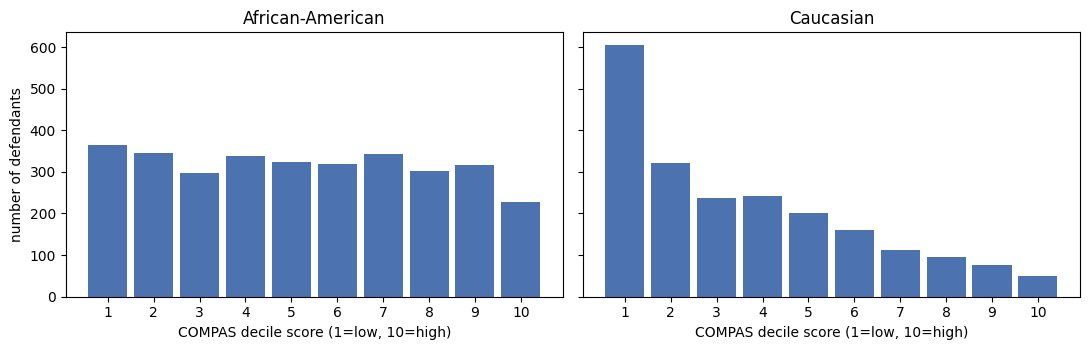

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, race in zip(axes, ["African-American", "Caucasian"]):
    sub = d[d.race == race]
    ax.hist(sub.decile_score, bins=range(1, 12), align="left",
            rwidth=0.85, color="#4C72B0")
    ax.set_title(race)
    ax.set_xlabel("COMPAS decile score (1=low, 10=high)")
    ax.set_xticks(range(1, 11))
axes[0].set_ylabel("number of defendants")
plt.tight_layout(); plt.show()

Caucasian defendants pile up at the low-risk end; scores for African-American defendants are spread much more evenly across the scale. That is suggestive — but a *distribution difference is not by itself bias*. Groups could differ in actual re-offense rates. We need to compare predictions **against what actually happened.**

## 4. Error rates by group (by hand)

These are the definitions from the lecture, written out. For each group we split predictions against outcomes into a confusion matrix and compute:

- **FPR** = of people who did *not* re-offend, what fraction were labeled high risk? *(slide: error-rate balance)*
- **FNR** = of people who *did* re-offend, what fraction were labeled low risk?
- **PPV** = of those labeled high risk, what fraction actually re-offended? *(slide: calibration / predictive parity)*

We compute them ourselves first — no library — so the numbers are demystified.

In [19]:
def group_rates(g):
    y, yhat = g.recid.values, g.high_risk.values
    TP = ((yhat == 1) & (y == 1)).sum()
    FP = ((yhat == 1) & (y == 0)).sum()
    TN = ((yhat == 0) & (y == 0)).sum()
    FN = ((yhat == 0) & (y == 1)).sum()
    return pd.Series({
        "n": len(g),
        "base_rate": y.mean(),         # P(actually re-offended)
        "FPR": FP / (FP + TN),
        "FNR": FN / (FN + TP),
        "PPV": TP / (TP + FP),         # predictive parity
    })

rates = d.groupby("race").apply(group_rates, include_groups=False)
rates

,n,base_rate,FPR,FNR,PPV
race,,,,,
African-American,3175.000,0.523,0.423,0.285,0.650
Caucasian,2103.000,0.391,0.220,0.496,0.595


This is ProPublica's headline. **Among people who did not re-offend, Black defendants were labeled high-risk about twice as often as white defendants (FPR).** The mirror image holds for false negatives: white defendants who *did* re-offend were far more likely to have been called low-risk. Let's draw it.

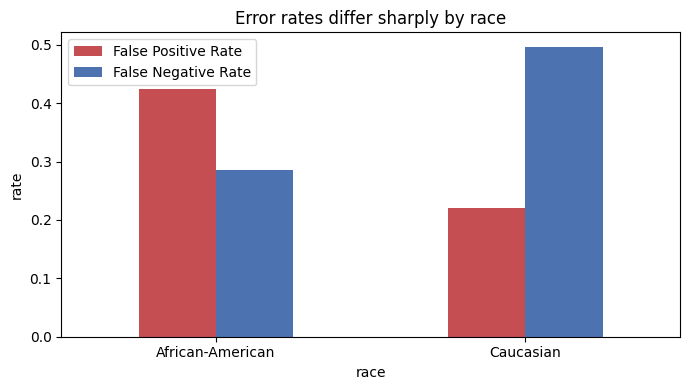

In [20]:
ax = rates[["FPR", "FNR"]].plot(kind="bar", figsize=(7, 4),
                                color=["#C44E52", "#4C72B0"], rot=0)
ax.set_ylabel("rate")
ax.set_title("Error rates differ sharply by race")
ax.legend(["False Positive Rate", "False Negative Rate"])
plt.tight_layout(); plt.show()

## 5. ...but COMPAS is calibrated

Northpointe (COMPAS's maker) defended the tool by pointing at a *different* fairness criterion: **calibration**. A score is calibrated if it means the same thing regardless of group — i.e. `P(re-offend | score, race)` does not depend on race.

Look at the PPV column above: it's similar across groups. Now look at the full calibration curve.

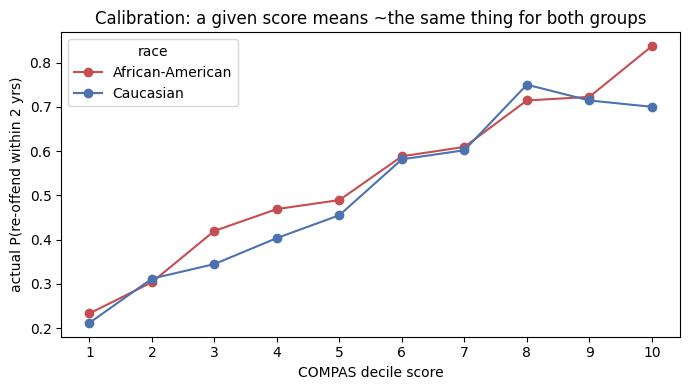

race,African-American,Caucasian
decile_score,,
1,0.233,0.212
2,0.303,0.312
3,0.419,0.345
4,0.469,0.403
5,0.489,0.455
6,0.588,0.581
7,0.609,0.602
8,0.714,0.750
9,0.722,0.714


In [21]:
cal = d.groupby(["race", "decile_score"]).recid.mean().unstack("race")
ax = cal.plot(marker="o", figsize=(7, 4),
              color={"African-American": "#C44E52", "Caucasian": "#4C72B0"})
ax.set_xlabel("COMPAS decile score")
ax.set_ylabel("actual P(re-offend within 2 yrs)")
ax.set_title("Calibration: a given score means ~the same thing for both groups")
ax.set_xticks(range(1, 11)); plt.tight_layout(); plt.show()
cal

The two curves nearly overlap. **By this definition COMPAS is fair.** So who is right — ProPublica or Northpointe? Both. They are measuring different things, and that is exactly the trap.

## 6. The impossibility result

This is the heart of Part 1 (Chouldechova 2017; Kleinberg, Mullainathan & Raghavan 2016). When two groups have **different base rates** of the outcome, no classifier (short of a perfect or trivial one) can simultaneously satisfy calibration *and* equal false-positive *and* equal false-negative rates.

Our data has exactly that precondition — check the base rates:

In [22]:
print("Base rate (actual re-offense rate) by group:")
print(rates["base_rate"])
print(f"\nDifference in base rates: {rates['base_rate'].diff().abs().iloc[-1]:.3f}")
print("\nBecause these base rates differ, calibration (Sec. 5) and "
      "error-rate balance (Sec. 4)\nCANNOT both hold. The data we just "
      "computed is that theorem made visible:\n"
      "  - calibration holds  -> Northpointe's claim\n"
      "  - error rates differ -> ProPublica's claim\n"
      "Both are true at once. The conflict is mathematical.")

Base rate (actual re-offense rate) by group:
race
African-American   0.523
Caucasian          0.391
Name: base_rate, dtype: float64

Difference in base rates: 0.132

Because these base rates differ, calibration (Sec. 5) and error-rate balance (Sec. 4)
CANNOT both hold. The data we just computed is that theorem made visible:
  - calibration holds  -> Northpointe's claim
  - error rates differ -> ProPublica's claim
Both are true at once. The conflict is mathematical.


## 7. "Fairness through unawareness" doesn't save you

A tempting fix from the slides: *just don't give the model race.* Let's test it directly. We train a logistic regression to predict re-offense using only age, prior counts, and juvenile-offense counts — **race is never an input** — and then measure error rates by race on a held-out set.

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from fairlearn.metrics import (MetricFrame, false_positive_rate,
                               false_negative_rate, selection_rate)

features = ["age", "priors_count", "juv_fel_count",
            "juv_misd_count", "juv_other_count"]   # note: race is NOT here
X, y, A = d[features].values, d.recid.values, d.race.values

Xtr, Xte, ytr, yte, Atr, Ate = train_test_split(
    X, y, A, test_size=0.3, random_state=RNG, stratify=y)
scaler = StandardScaler().fit(Xtr)

clf = LogisticRegression(max_iter=1000).fit(scaler.transform(Xtr), ytr)
yp = clf.predict(scaler.transform(Xte))

mf = MetricFrame(
    metrics={"accuracy": accuracy_score,
             "FPR": false_positive_rate,
             "FNR": false_negative_rate,
             "selection_rate": selection_rate},
    y_true=yte, y_pred=yp, sensitive_features=Ate)

print(f"Overall accuracy: {accuracy_score(yte, yp):.3f}")
print(f"FPR gap between groups: {mf.difference()['FPR']:.3f}\n")
mf.by_group

Overall accuracy: 0.690
FPR gap between groups: 0.118



,accuracy,FPR,FNR,selection_rate
sensitive_feature_0,,,,
African-American,0.700,0.263,0.335,0.471
Caucasian,0.674,0.144,0.608,0.242


The disparity is still there. **Hiding race does not hide the information** — features like prior-arrest counts act as proxies, because they were themselves shaped by unequal policing. This is precisely the "proxy" caveat on the *fairness-through-unawareness* slide.

## 8. The accuracy–fairness tradeoff

If unawareness doesn't work, can we *enforce* a fairness criterion? `fairlearn`'s `ThresholdOptimizer` adjusts decision thresholds per group to equalize a chosen metric. We ask it for **equal false-positive rates** and see what it costs.

In [24]:
from fairlearn.postprocessing import ThresholdOptimizer

opt = ThresholdOptimizer(
    estimator=LogisticRegression(max_iter=1000),
    constraints="false_positive_rate_parity",
    objective="accuracy_score",
    prefit=False)
opt.fit(scaler.transform(Xtr), ytr, sensitive_features=Atr)
yp_fair = opt.predict(scaler.transform(Xte), sensitive_features=Ate)

mf_fair = MetricFrame(
    metrics={"FPR": false_positive_rate, "FNR": false_negative_rate},
    y_true=yte, y_pred=yp_fair, sensitive_features=Ate)

print("BEFORE  -> accuracy {:.3f},  FPR gap {:.3f}".format(
    accuracy_score(yte, yp), mf.difference()["FPR"]))
print("AFTER   -> accuracy {:.3f},  FPR gap {:.3f}".format(
    accuracy_score(yte, yp_fair), mf_fair.difference()["FPR"]))
mf_fair.by_group

BEFORE  -> accuracy 0.690,  FPR gap 0.118
AFTER   -> accuracy 0.674,  FPR gap 0.006


,FPR,FNR
sensitive_feature_0,,
African-American,0.208,0.453
Caucasian,0.202,0.485


The FPR gap nearly vanishes — and overall accuracy drops a little. That tension is the *accuracy–fairness tradeoff* curve from the slides, made real. There is no free lunch: equalizing one fairness metric spends something, and (per Section 6) it necessarily unbalances another.

## Open questions & things to play with

No single right answer here — these are the questions the lecture wants you arguing about.

**On definitions**
1. We equalized FPR. Re-run Section 8 with `constraints="equalized_odds"` or `"demographic_parity"`. Which metric "should" a court equalize? Notice you are now making a **values** choice, not a technical one.
2. Section 6 says you can't satisfy everything. If you were deploying this, **which guarantee would you give up, and to whom does that decision transfer the risk?** (slide: *Who bears the risk of errors?*)

**On the data and framing**

3. We dropped every group except two. Re-include Hispanic and other defendants. Do the conclusions hold? What does it mean that the standard analysis quietly studies only two groups?
4. The outcome is "re-arrested within 2 years," not "committed a crime." How does using *arrest* as a proxy for *crime* bake existing policing patterns into the label — and therefore into any model trained on it?
5. Should a tool like this be built at all? (slide: *from "can we?" to "should we?"*) What would have to be true about the data, the deployment, and the oversight for you to be comfortable?

**Going further (and a bridge to the next labs)**

6. Try richer features or a different classifier (random forest, gradient boosting). Does a more accurate model become *more* or *less* fair? Why might that be?
7. **LLM-as-judge audit (uses your Groq credits).** Modern systems increasingly let an LLM make or recommend these calls. Give the model the same case features and ask it for a risk judgment, then run the *exact same* `MetricFrame` audit on its outputs:

```python
# Groq first, with a local LLM fallback (see README → "Local backup server").
import os
from groq import Groq
try:
    from dotenv import load_dotenv          # local: reads GROQ_API_KEY / LLM_* from .env
    load_dotenv()
except ImportError:
    pass
try:
    from google.colab import userdata       # Colab: reads the GROQ_API_KEY secret
    os.environ.setdefault("GROQ_API_KEY", userdata.get("GROQ_API_KEY"))
except Exception:
    pass

GROQ_MODEL   = "llama-3.3-70b-versatile"
LLM_BASE_URL = os.environ.get("LLM_BASE_URL", "http://localhost:8000/v1")
LLM_MODEL    = os.environ.get("LLM_MODEL", "Qwen/Qwen2.5-3B-Instruct")
groq_client  = Groq() if os.environ.get("GROQ_API_KEY") else None

def chat(prompt):
    """Groq first; on failure (or no key) fall back to the local LLM server."""
    if groq_client is not None:
        try:
            return groq_client.chat.completions.create(
                model=GROQ_MODEL,
                messages=[{"role": "user", "content": prompt}]).choices[0].message.content
        except Exception as e:
            print(f"  Groq failed ({type(e).__name__}); using local LLM at {LLM_BASE_URL}")
    from openai import OpenAI
    local = OpenAI(api_key="EMPTY", base_url=LLM_BASE_URL)
    return local.chat.completions.create(
        model=LLM_MODEL,
        messages=[{"role": "user", "content": prompt}]).choices[0].message.content

def llm_risk(row):
    msg = (f"A defendant is age {row.age} with {row.priors_count} prior "
           f"offenses. Reply with ONLY 'high' or 'low' risk of re-offending.")
    return int("high" in chat(msg).lower())

# Sample a small subset (API calls cost credits) and audit by race exactly
# as in Section 4. Is the LLM calibrated? Are its error rates balanced?
```
   Does the LLM reproduce the same disparities? Does telling it to "be fair" change anything measurable — or just the wording? This is the hand-off to **Part 2 (Fighting Words)**, where you'll measure bias in *language itself*, and then collect and audit model-generated text of your own.